Trabajo Computacional 1 - Aceleradores y detectores de partículas 

Grupo: Catalina Fuentes (202220750), Daniela León (), David Cantini ()

PARTE 1 - MONOCROMADOR

Resultado (cuando theta ~ 180°):
x_salida = -1.000003
y_salida = -0.000004
R_salida = 1.000003
-R (desde x) ~ 1.000003


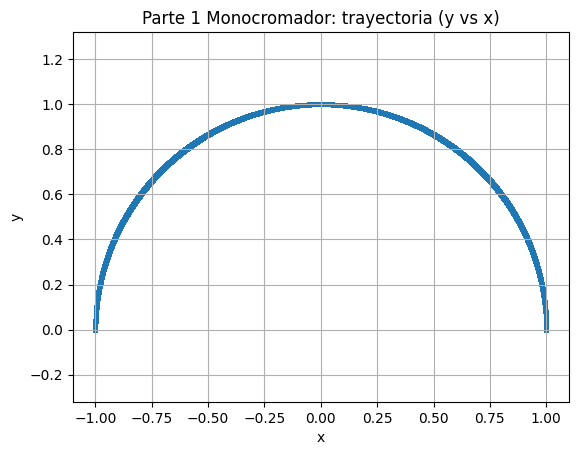

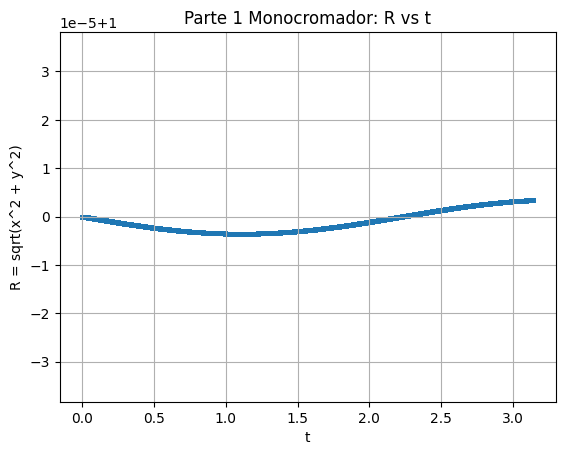

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# En esta Parte 1 (Monocromador) simulamos el movimiento de una partícula cargada en un campo magnético uniforme.
# La guía propone usar la magnitud de la fuerza magnética como F = q * v * B y tratarla como fuerza centrípeta.
# Eso significa que la fuerza siempre apunta hacia el centro (el origen) y su dirección es -r_hat = -(x/R, y/R).
# Con esto, la trayectoria ideal es un círculo (y si paramos en 180 grados, vemos medio círculo).

# Numéricamente, la guía sugiere avanzar en pasos pequeños de tiempo dt usando Euler-Feynman/Euler-Cromer:
# 1) Calculamos aceleración a = F/M en el instante actual.
# 2) Actualizamos velocidades: v_new = v_old + a*dt
# 3) Actualizamos posiciones: x_new = x_old + v_new*dt
# Esto es importante porque este esquema suele ser más estable que el Euler “simple” para movimientos tipo oscilatorio/circular.

# Parámetros físicos y numéricos
M = 1.0          # masa de la partícula (unidades normalizadas)
q = 1.0          # carga de la partícula (unidades normalizadas)
B = 1.0          # campo magnético uniforme (magnitud, unidades normalizadas)
dt = 1e-5        # paso de tiempo (la guía insiste en que sea muy pequeño)
t_max = 10.0     # tiempo máximo por seguridad (idealmente el criterio real de parada es theta = pi)

# Condiciones iniciales
# Arrancamos en (R0, 0) con velocidad inicial hacia +y, lo cual genera una trayectoria circular alrededor del origen.
R0 = 1.0
x = R0
y = 0.0
vx = 0.0
vy = 1.0

# Listas para guardar datos y poder hacer los plots que pide la guía:
# 1) Trayectoria (y vs x)
# 2) Radio R vs tiempo t
xs, ys, ts, Rs = [], [], [], []

t = 0.0
theta = 0.0

# Bucle principal de la simulación:
# La guía pide detenernos cuando el ángulo theta llegue a 180 grados, es decir pi radianes.
while t <= t_max and theta < np.pi:

    # Radio instantáneo R (distancia al origen). Esto se usa tanto para la dirección radial como para el plot R vs t.
    R = np.sqrt(x**2 + y**2)

    # Rapidez instantánea v (magnitud de la velocidad). La guía usa v para la magnitud de la fuerza q*v*B.
    v = np.sqrt(vx**2 + vy**2)

    # Evitar división por cero por si (por alguna razón numérica) la partícula cae exactamente en el origen.
    if R == 0:
        break

    # Fuerza magnética según la guía:
    # Magnitud: |F| = q * v * B
    # Dirección: hacia el centro -> -r_hat = -(x/R, y/R)
    # Por eso las componentes quedan:
    # Fx = - q*v*B * (x/R)
    # Fy = - q*v*B * (y/R)
    Fx = -q * v * B * (x / R)
    Fy = -q * v * B * (y / R)

    # Aceleración por segunda ley de Newton: a = F / M
    ax = Fx / M
    ay = Fy / M

    # Integración numérica tipo Euler-Feynman / Euler-Cromer (como en la guía):
    # Primero actualizamos velocidad con la aceleración actual,
    # y con esa velocidad nueva actualizamos la posición.
    vx = vx + ax * dt
    vy = vy + ay * dt
    x = x + vx * dt
    y = y + vy * dt

    # Avanzamos el tiempo
    t = t + dt

    # Guardamos los valores para graficar después.
    xs.append(x)
    ys.append(y)
    ts.append(t)
    Rs.append(np.sqrt(x**2 + y**2))

    # Cálculo del ángulo theta:
    # La guía menciona theta = arctan(y/x). El problema de arctan(y/x) es que por defecto devuelve valores
    # en (-pi/2, pi/2), entonces hay ambigüedad de cuadrante cuando x cambia de signo.
    # Para seguir la idea de la guía pero hacer que funcione el criterio “llegar a pi”, calculamos arctan(y/x)
    # y luego corregimos el cuadrante usando el signo de x y y.
    if x != 0:
        theta = np.arctan(y / x)
    else:
        # Si x = 0, y/x no existe. En ese caso, el ángulo es pi/2 si y>0 o -pi/2 si y<0.
        theta = (np.pi / 2) if (y > 0) else (-np.pi / 2)

    # Corrección de cuadrante para tener theta en el rango [0, 2*pi)
    # - Si x < 0, el punto está en el cuadrante II o III, entonces sumamos pi.
    # - Si x > 0 pero y < 0, está en el cuadrante IV, entonces sumamos 2*pi para hacerlo positivo.
    if x < 0:
        theta = theta + np.pi
    elif y < 0:
        theta = theta + 2*np.pi

# Al terminar el while, idealmente estamos cerca del punto de salida cuando theta ~ pi (180 grados).
# La guía menciona que al llegar a 180 grados el punto debería estar cerca de (-R, 0).
x_exit = xs[-1] if xs else x
y_exit = ys[-1] if ys else y
R_exit = np.sqrt(x_exit**2 + y_exit**2)

print("Resultado (cuando theta ~ 180°):")
print(f"x_salida = {x_exit:.6f}")
print(f"y_salida = {y_exit:.6f}")
print(f"R_salida = {R_exit:.6f}")
print(f"-R (desde x) ~ {-x_exit:.6f}")

# Plot 1: Scatterplot y vs x (trayectoria)
# Esto es uno de los entregables que pide la guía.
plt.figure()
plt.scatter(xs, ys, s=6)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parte 1 Monocromador: trayectoria (y vs x)")
plt.axis("equal")  # importante para que el círculo se vea como círculo y no como elipse por la escala
plt.grid(True)
plt.show()

# Plot 2: Scatterplot R vs t
# Aquí se ve si el radio se mantiene aproximadamente constante, como se espera para movimiento circular ideal.
plt.figure()
plt.scatter(ts, Rs, s=6)
plt.xlabel("t")
plt.ylabel("R = sqrt(x^2 + y^2)")
plt.title("Parte 1 Monocromador: R vs t")
plt.grid(True)

# Ajuste visual de la escala del eje y:
# Esto no cambia los datos, solo aleja o acerca la ventana de visualización
Rmin, Rmax = np.min(Rs), np.max(Rs)
margin = 5 * (Rmax - Rmin)
plt.ylim(Rmin - margin, Rmax + margin)

plt.show()


PARTE 2.1 - MONOCROMADOR EXTENDIENDO ANGULO A 360 GRADOS: SINCROTRÓN IDEALIZADO

Resultado (cuando theta ~ 360°):
x_final = 0.408064
y_final = 0.912953
R_final = 1.000000


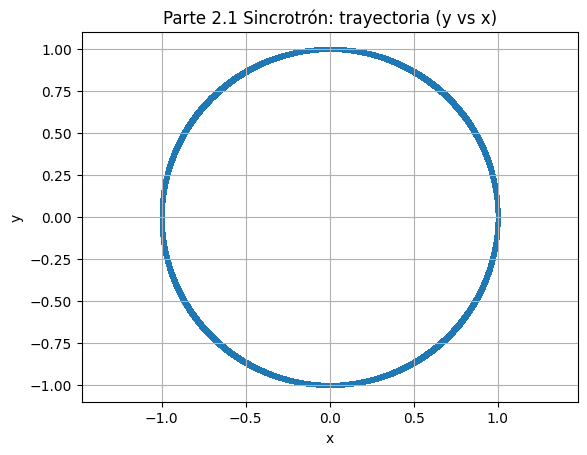

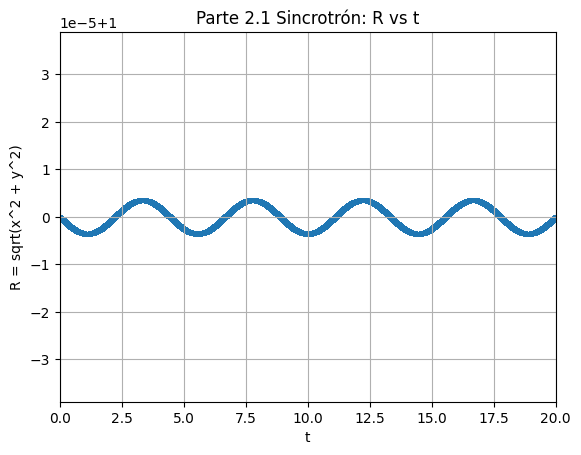

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# En la Parte 2.1 (Sincrotrón idealizado) hacemos prácticamente lo mismo que en el monocromador,
# pero ahora no paramos en 180 grados sino en 360 grados (una vuelta completa).
# La física es la misma del modelo de la guía: usamos una fuerza magnética de magnitud F = q * v * B
# y la tratamos como fuerza centrípeta apuntando hacia el centro (origen).

# El objetivo de esta parte es ver que la partícula puede dar una vuelta completa en una órbita circular,
# y verificar con los plots que:
# 1) La trayectoria en el plano x-y es (casi) un círculo.
# 2) El radio R = sqrt(x^2 + y^2) se mantiene aproximadamente constante en el tiempo.

# Parámetros
M = 1.0          # masa (unidades normalizadas)
q = 1.0          # carga (unidades normalizadas)
B = 1.0          # campo magnético uniforme (magnitud)
dt = 1e-5        # paso de tiempo pequeño para estabilidad numérica
t_max = 20.0     # tiempo máximo (por seguridad; la simulación idealmente termina por theta = 2*pi)

# Condiciones iniciales
# Arrancamos en (R0, 0) y con velocidad hacia +y para que la partícula empiece girando alrededor del origen.
R0 = 1.0
x = R0
y = 0.0
vx = 0.0
vy = 1.0

# Listas para guardar datos y hacer los plots que pide la guía (trayectoria y radio vs tiempo)
xs, ys, ts, Rs = [], [], [], []

t = 0.0
theta = 0.0

# Bucle principal:
# En esta parte paramos cuando theta llegue a 2*pi (360 grados), es decir, una vuelta completa.
while t <= t_max and theta < 2*np.pi:

    # Radio instantáneo R (distancia al centro)
    R = np.sqrt(x**2 + y**2)

    # Rapidez instantánea v (magnitud de la velocidad)
    v = np.sqrt(vx**2 + vy**2)

    # Evitar división por cero si por errores numéricos se llega al origen
    if R == 0:
        break

    # Fuerza según la guía:
    # Magnitud: |F| = q * v * B
    # Dirección: hacia el centro -> -r_hat = -(x/R, y/R)
    Fx = -q * v * B * (x / R)
    Fy = -q * v * B * (y / R)

    # Aceleración: a = F / M
    ax = Fx / M
    ay = Fy / M

    # Integración Euler-Feynman / Euler-Cromer:
    # 1) actualizar velocidades con la aceleración
    # 2) actualizar posiciones con las velocidades nuevas
    vx = vx + ax * dt
    vy = vy + ay * dt
    x = x + vx * dt
    y = y + vy * dt

    # Avanzar tiempo
    t = t + dt

    # Guardar datos para los plots
    xs.append(x)
    ys.append(y)
    ts.append(t)
    Rs.append(np.sqrt(x**2 + y**2))

    # Cálculo del ángulo theta con la idea de la guía (arctan(y/x)):
    # Igual que en Parte 1, arctan(y/x) por sí solo no distingue bien el cuadrante,
    # entonces corregimos el cuadrante usando el signo de x y y.
    if x != 0:
        theta = np.arctan(y / x)
    else:
        theta = (np.pi / 2) if (y > 0) else (-np.pi / 2)

    # Corrección de cuadrante para dejar theta en [0, 2*pi)
    if x < 0:
        theta = theta + np.pi
    elif y < 0:
        theta = theta + 2*np.pi

# Resultado al llegar a 360°
# Idealmente, después de una vuelta completa la partícula debería regresar cerca del punto inicial (R0, 0).
x_exit = xs[-1] if xs else x
y_exit = ys[-1] if ys else y
R_exit = np.sqrt(x_exit**2 + y_exit**2)

print("Resultado (cuando theta ~ 360°):")
print(f"x_final = {x_exit:.6f}")
print(f"y_final = {y_exit:.6f}")
print(f"R_final = {R_exit:.6f}")

# Plot 1: Scatterplot y vs x (trayectoria)
# Debe verse (idealmente) como un círculo completo.
plt.figure()
plt.scatter(xs, ys, s=6)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parte 2.1 Sincrotrón: trayectoria (y vs x)")
plt.axis("equal")
plt.grid(True)
plt.show()

# Plot 2: Scatterplot R vs t
# Debe verse aproximadamente constante si la órbita es circular estable.
plt.figure()
plt.scatter(ts, Rs, s=6)
plt.xlabel("t")
plt.ylabel("R = sqrt(x^2 + y^2)")
plt.title("Parte 2.1 Sincrotrón: R vs t")
plt.grid(True)

# Mostramos el eje x solo hasta donde realmente hay datos (la simulación para al llegar a 2*pi)
plt.xlim(0, ts[-1])

# Ajuste de escala 
Rmin, Rmax = np.min(Rs), np.max(Rs)
margin = 5 * (Rmax - Rmin)
plt.ylim(Rmin - margin, Rmax + margin)

plt.show()
